### Task 1

To complete the task:
1. Choose the function as in the table
2. Visualize the graph of X1, X2 from -50 to +50
3. Use brute force search, gradient descent, simulated annealing, genetic algorythm and pattern search (hooke jeeves). For the optimization sequence you are allowed to use numpy only.
4. Visualize the graph with points of optimums from different methods.

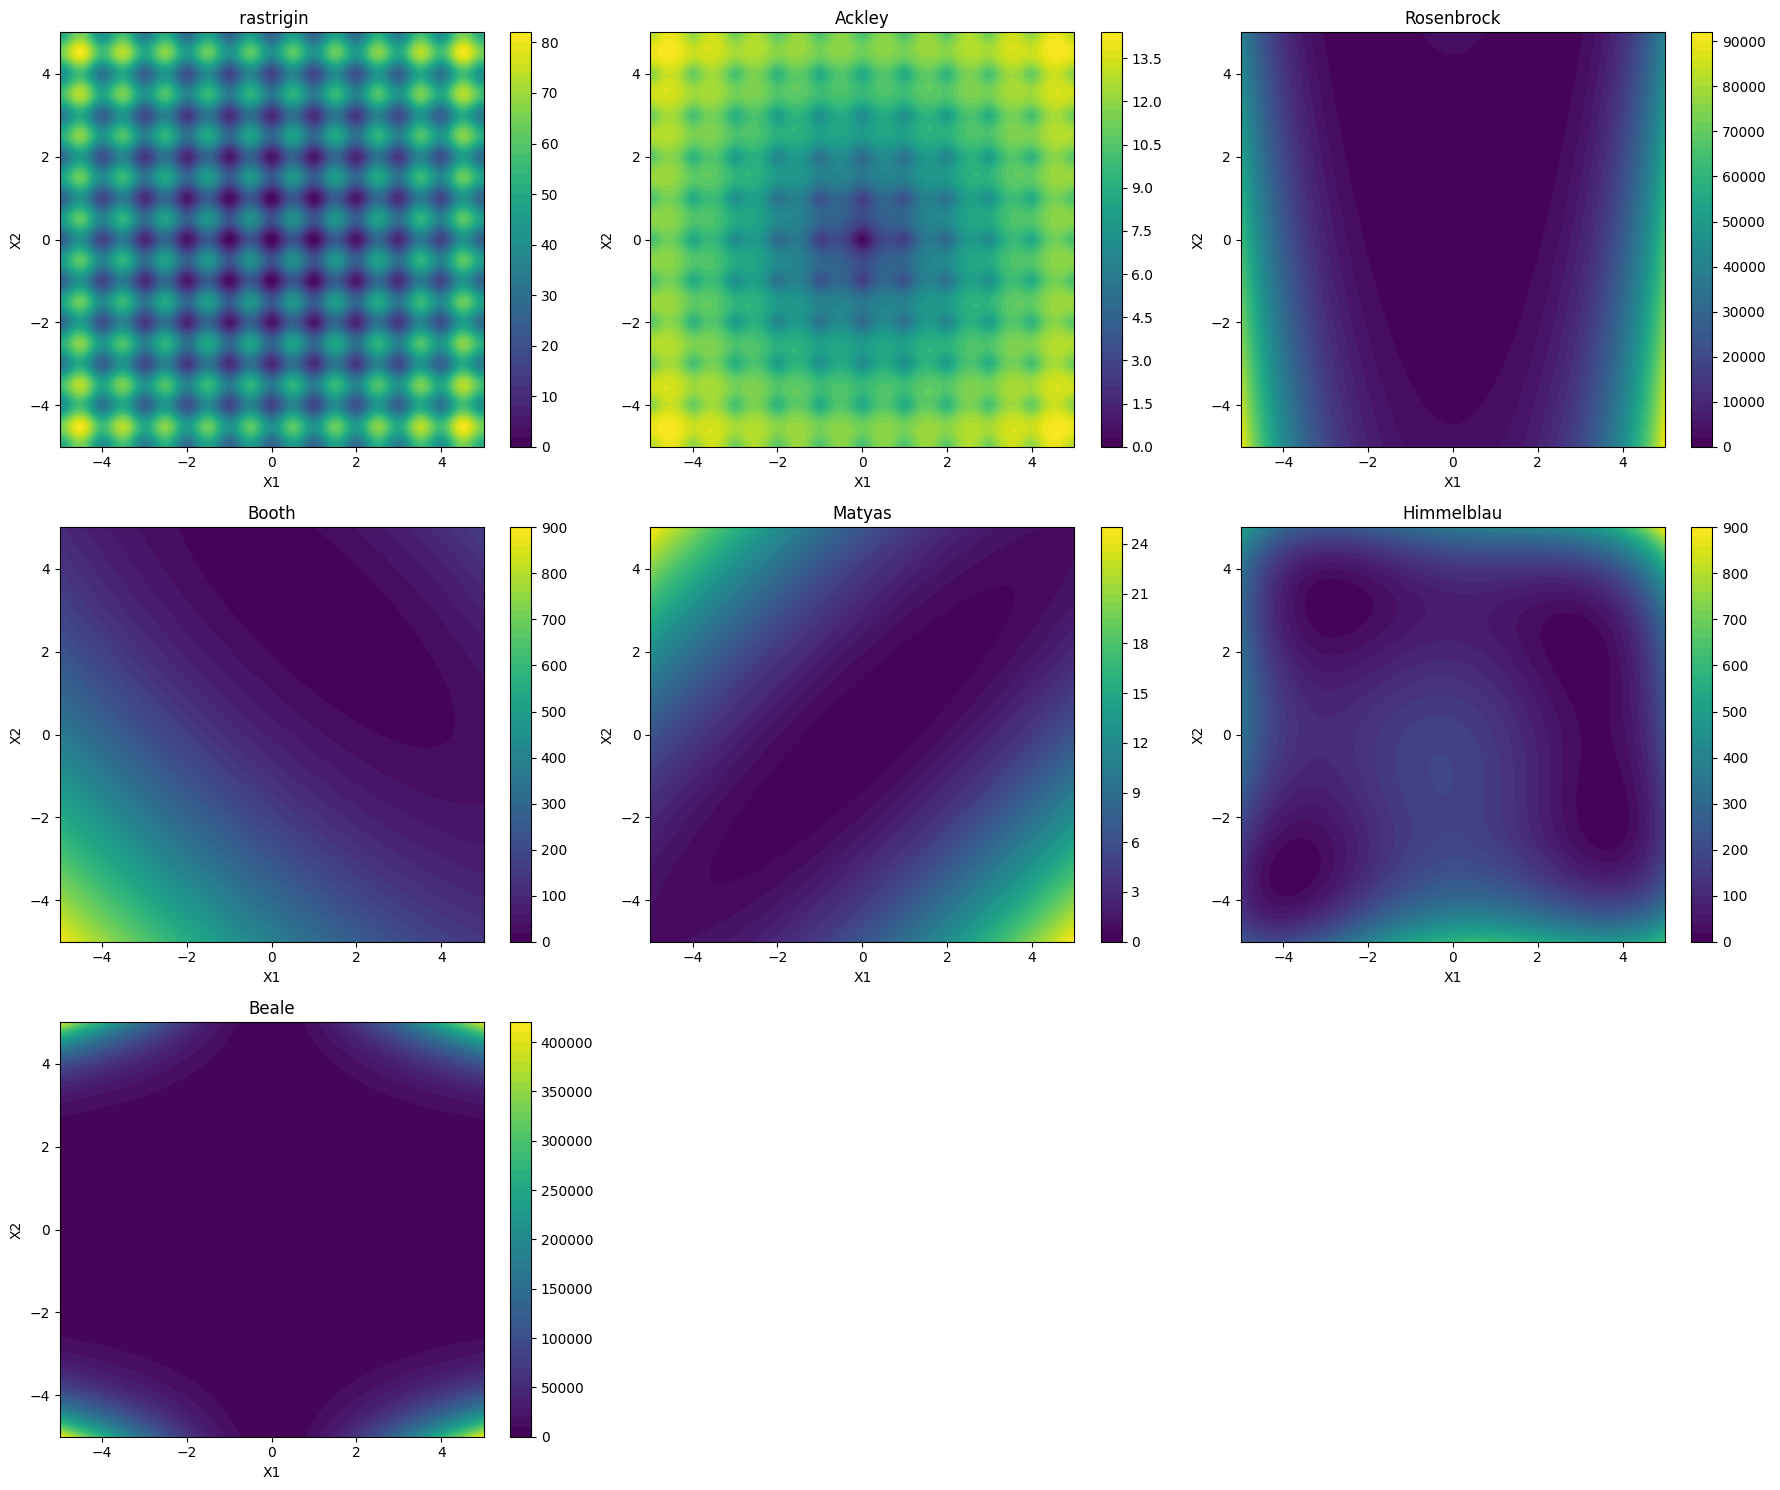

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, sympify, lambdify, pi, E,  cos, sqrt, exp

# Define symbols
X1, X2 = symbols('X1 X2')
symbolic_functions = {
    " rastrigin": 20 + X1**2 - 10*cos(2*pi*X1) + X2**2 - 10*cos(2*pi*X2),
    "ackley": -20*exp(-0.2*sqrt(0.5*(X1**2 + X2**2))) - exp(0.5*(cos(2*pi*X1) + cos(2*pi*X2))) + E + 20,
    "rosenbrock": (1 - X1)**2 + 100*(X2 - X1**2)**2,
    "booth": (X1 + 2*X2 - 7)**2 + (2*X1 + X2 - 5)**2,
    "matyas": 0.26*(X1**2 + X2**2) - 0.48*X1*X2,
    "himmelblau": (X1**2 + X2 - 11)**2 + (X1 + X2**2 - 7)**2,
    "beale": (1.5 - X1 + X1*X2)**2 + (2.25 - X1 + X1*X2**2)**2 + (2.625 - X1 + X1*X2**3)**2
}

# Create meshgrid
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)

# Evaluate and plot each function
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (name, expr_str) in enumerate(symbolic_functions.items()):
    expr = sympify(expr_str)
    func = lambdify((X1, X2), expr, modules=['numpy', {'E': np.e, 'pi': np.pi}])
    Z = func(X, Y)

    ax = axes[i]
    contour = ax.contourf(X, Y, Z, levels=50, cmap='viridis')
    ax.set_title(name.capitalize())
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    fig.colorbar(contour, ax=ax)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

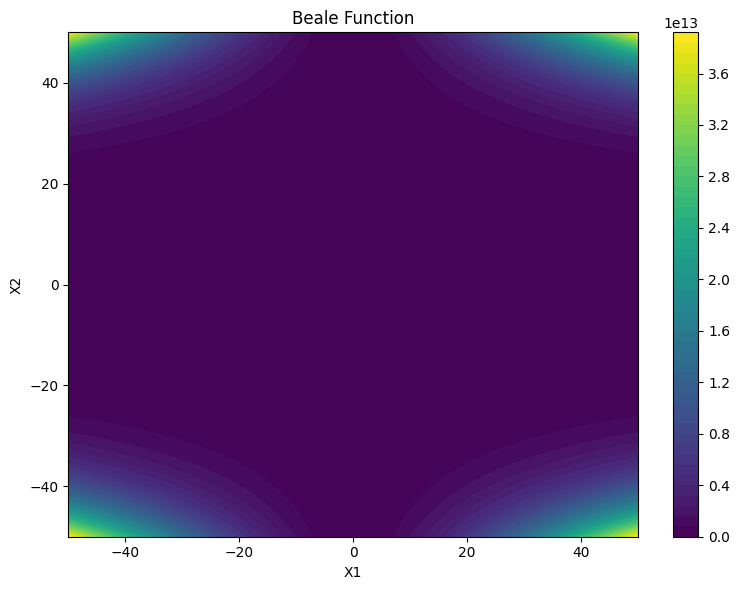

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, sympify, lambdify, pi, E, cos, sqrt, exp

# Define symbols
X1, X2 = symbols('X1 X2')

# Only the Beale function
beale_expr = (1.5 - X1 + X1*X2)**2 + (2.25 - X1 + X1*X2**2)**2 + (2.625 - X1 + X1*X2**3)**2

# Create meshgrid
x = np.linspace(-50, 50, 400)
y = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x, y)

# Evaluate the function
beale_func = lambdify((X1, X2), beale_expr, modules=['numpy', {'pi': np.pi}])
Z = beale_func(X, Y)

# Plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.title('Beale Function')
plt.xlabel('X1')
plt.ylabel('X2')
plt.colorbar(contour)
plt.tight_layout()
plt.show()


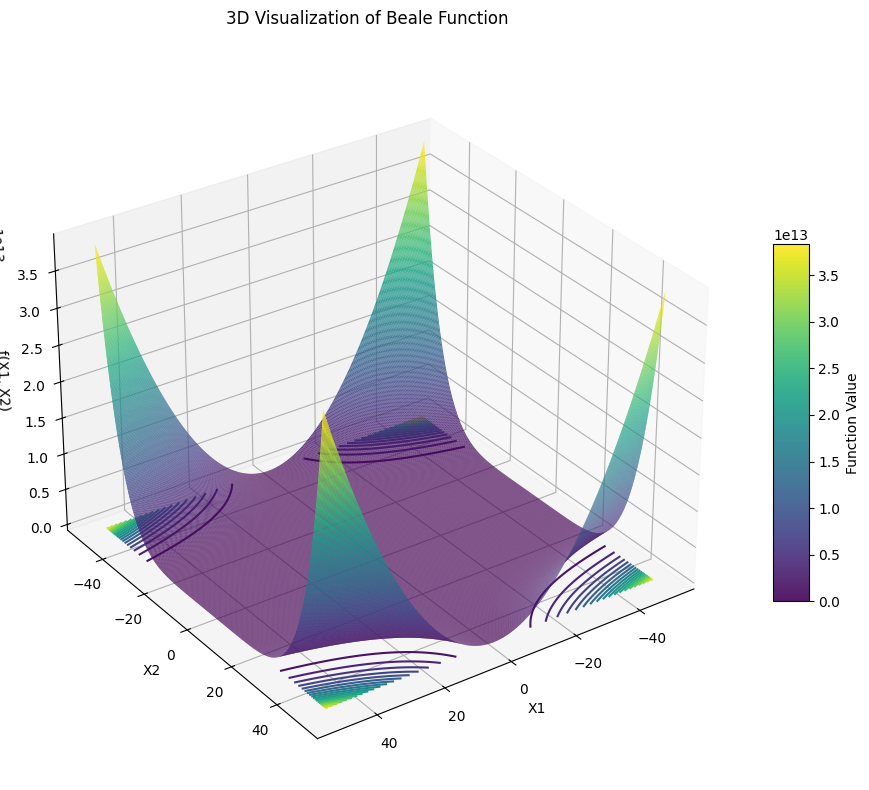

In [64]:
# 3D plot
x = np.linspace(-50, 50, 400)
y = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x, y)
Z = beale_func(X, Y)

# Create 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9, rstride=1, cstride=1, antialiased=True)

# Contour projection on Z axis
ax.contour(X, Y, Z, zdir='z', offset=Z.min(), cmap='viridis', levels=20)

# Colorbar
cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
cbar.set_label('Function Value')

# Labels and view)
ax.view_init(elev=30, azim=55)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('f(X1, X2)')
ax.set_title('3D Visualization of Beale Function', pad=30)

ax.grid(True)

plt.tight_layout()
plt.show()

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# Beale function definition (vectorized for plotting and scalar for evaluation)
def beale(x1, x2):
    A = 1.5
    B = 2.25
    C = 2.625
    return (A - x1 + x1*x2)**2 + (B - x1 + x1*x2**2)**2 + (C - x1 + x1*x2**3)**2

# Brute force search implementation
def brute_force_search(func, bounds, step):
    # Create a grid of points to search
    x1_values = np.arange(bounds[0][0], bounds[0][1] + step, step)
    x2_values = np.arange(bounds[1][0], bounds[1][1] + step, step)

    best_x = None
    best_func_value = float('inf')

    # Iterate over all points in the grid
    for x1 in x1_values:
        for x2 in x2_values:
            func_value = func(x1, x2)

            # Update best_x and best_func_value if a better value is found
            if func_value < best_func_value:
                best_func_value = func_value
                best_x = np.array([x1, x2])

    return best_x, best_func_value

# Search bounds and step size
bounds = [(-10, 10), (-10, 10)]
step = 0.1

# Run brute force search
best_x, best_func_value = brute_force_search(beale_func, bounds, step)

# Print results
print("Minimum found at:", best_x)
print("Function value at minimum:", best_func_value)

Minimum found at: [3.  0.5]
Function value at minimum: 1.5546007903480615e-26


In [144]:
import numpy as np
import matplotlib.pyplot as plt

# Beale function
def beale(x1, x2):
    A = 1.5
    B = 2.25
    C = 2.625
    return (A - x1 + x1*x2)**2 + (B - x1 + x1*x2**2)**2 + (C - x1 + x1*x2**3)**2

# Gradient of Beale function
def beale_grad(x):
    x1, x2 = x[0], x[1]
    A, B, C = 1.5, 2.25, 2.625

    df_dx1 = 2*(A - x1 + x1*x2)*(-1 + x2) \
           + 2*(B - x1 + x1*x2**2)*(-1 + x2**2) \
           + 2*(C - x1 + x1*x2**3)*(-1 + x2**3)

    df_dx2 = 2*(A - x1 + x1*x2)*(x1) \
           + 2*(B - x1 + x1*x2**2)*(2*x1*x2) \
           + 2*(C - x1 + x1*x2**3)*(3*x1*x2**2)

    return np.array([df_dx1, df_dx2])

# Gradient Descent implementation
def gradient_descent(func, grad_func, x0, learning_rate=0.01, max_iter=100, tol=1e-6):
    x = x0.copy()
    for i in range(max_iter):
        grad = grad_func(x)
        x -= learning_rate * grad
        if np.linalg.norm(grad) < tol:
            break
    return x, func(x[0], x[1])

# Use a smaller initial point to avoid overflow
x0 = np.array([1.0, 1.0], dtype=np.float64)

# Run gradient descent
best_x_gd, best_func_value_gd = gradient_descent(beale, beale_grad, x0)

# Print results
print("Minimum found at (Gradient Descent):", best_x_gd)
print("Function value at minimum (Gradient Descent):", best_func_value_gd)


Minimum found at (Gradient Descent): [2.48134763 0.33747324]
Function value at minimum (Gradient Descent): 0.08048171488926333


In [185]:
import numpy as np

# Beale function
def beale(x):
    x1, x2 = x[0], x[1]
    A, B, C = 1.5, 2.25, 2.625
    return (A - x1 + x1*x2)**2 + (B - x1 + x1*x2**2)**2 + (C - x1 + x1*x2**3)**2

# Simulated Annealing implementation
def simulated_annealing(func, bounds, initial_temp=1000, cooling_rate=0.95, max_iter=1000):
    """Simulated Annealing method."""

    # Initialization
    current_state = np.random.uniform(bounds[0][0], bounds[0][1], size=2)
    current_energy = func(current_state)
    best_state = current_state.copy()
    best_energy = current_energy
    temp = initial_temp

    # Main loop
    for i in range(max_iter):
        # Generate new state
        neighbor = current_state + np.random.normal(scale=0.5, size=2)
        neighbor = np.clip(neighbor, bounds[0][0], bounds[0][1])  # Enforce bounds

        # Calculate energy of new state
        neighbor_energy = func(neighbor)

        # Accept or reject new state
        delta_energy = neighbor_energy - current_energy
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / temp):
            current_state = neighbor
            current_energy = neighbor_energy

            # Update best state if better
            if current_energy < best_energy:
                best_state = current_state.copy()
                best_energy = current_energy

        # Cooling
        temp *= cooling_rate

    return best_state, best_energy

# Search bounds for X1 and X2
bounds = [(-10, 10), (-10, 10)]  # Adjusted to better suit Beale function's landscape

# Run Simulated Annealing
best_x_sa, best_func_value_sa = simulated_annealing(beale, bounds)

# Print results
print("Minimum found at (Simulated Annealing):", best_x_sa)
print("Function value at minimum (Simulated Annealing):", best_func_value_sa)

Minimum found at (Simulated Annealing): [-4.49966627  1.1838218 ]
Function value at minimum (Simulated Annealing): 0.7655356563190641


In [186]:
import numpy as np

# Beale function
def beale(x):
    x1, x2 = x[0], x[1]
    A, B, C = 1.5, 2.25, 2.625
    return (A - x1 + x1*x2)**2 + (B - x1 + x1*x2**2)**2 + (C - x1 + x1*x2**3)**2

# Genetic Algorithm
def genetic_algorithm(func, bounds, pop_size=50, num_generations=200, mutation_rate=0.1):
    """Genetic Algorithm implementation."""

    # Initialize population
    population = np.random.uniform(bounds[0][0], bounds[0][1], size=(pop_size, 2))

    for generation in range(num_generations):
        # Evaluate fitness
        fitness = np.array([func(individual) for individual in population])
        fitness = -fitness  # We want to minimize the function
        fitness = fitness + abs(fitness.min()) + 1e-6  # Shift to make all values positive

        # Selection
        parents_idx = np.random.choice(np.arange(pop_size), size=pop_size, replace=True, p=fitness / fitness.sum())
        parents = population[parents_idx]

        # Crossover
        offspring = np.zeros_like(parents)
        crossover_point = np.random.randint(0, 2, size=pop_size)  # Random crossover point
        for i in range(pop_size):
            offspring[i] = np.where(crossover_point[i], parents[i], parents[(i + 1) % pop_size])

        # Mutation
        mutation_mask = np.random.rand(*offspring.shape) < mutation_rate
        mutations = np.random.uniform(bounds[0][0], bounds[0][1], size=offspring.shape)
        offspring[mutation_mask] = mutations[mutation_mask]

        # Replace population
        population = offspring

    # Find the best individual
    final_fitness = np.array([func(individual) for individual in population])
    best_idx = np.argmin(final_fitness)  # Use actual (non-negated) function value for best
    best_x = population[best_idx]
    best_func_value = func(best_x)

    return best_x, best_func_value

# Search bounds for X1 and X2
bounds = [(-10, 10), (-10, 10)]  # Suitable range for Beale function

# Run Genetic Algorithm
best_x_ga, best_func_value_ga = genetic_algorithm(beale, bounds)

# Print results
print("Minimum found at (Genetic Algorithm):", best_x_ga)
print("Function value at minimum (Genetic Algorithm):", best_func_value_ga)


Minimum found at (Genetic Algorithm): [ 0.94199032 -1.02097892]
Function value at minimum (Genetic Algorithm): 5.869880736347978


In [187]:
import numpy as np

# Beale function
def beale(x):
    x1, x2 = x[0], x[1]
    A, B, C = 1.5, 2.25, 2.625
    return (A - x1 + x1*x2)**2 + (B - x1 + x1*x2**2)**2 + (C - x1 + x1*x2**3)**2

# Pattern Search (Hooke-Jeeves method)
def pattern_search(func, x0, step_size=1, step_reduction_factor=0.5, min_step_size=1e-6, max_iter=1000):
    """Pattern Search (Hooke-Jeeves method) for function minimization."""

    x = x0.copy()
    best_x = x.copy()
    best_func_value = func(x)

    for _ in range(max_iter):
        improved = False

        # Exploratory search
        for i in range(len(x)):
            for direction in [-1, 1]:
                x_candidate = x.copy()
                x_candidate[i] += direction * step_size
                func_value_candidate = func(x_candidate)

                if func_value_candidate < best_func_value:
                    best_func_value = func_value_candidate
                    best_x = x_candidate.copy()
                    improved = True

        # If no improvement, reduce the step size
        if not improved:
            step_size *= step_reduction_factor
            if step_size < min_step_size:
                break
        else:
            # Pattern move
            x_pattern = best_x + (best_x - x)
            func_value_pattern = func(x_pattern)

            if func_value_pattern < best_func_value:
                best_func_value = func_value_pattern
                best_x = x_pattern.copy()

            x = best_x.copy()

    return best_x, best_func_value

# Initial guess
x0 = np.array([5.0,5.0])

# Run pattern search with Beale function
best_x_ps, best_func_value_ps = pattern_search(beale, x0)

# Print results
print("Minimum found at (Pattern Search):", best_x_ps)
print("Function value at minimum (Pattern Search):", best_func_value_ps)


Minimum found at (Pattern Search): [3.  0.5]
Function value at minimum (Pattern Search): 0.0


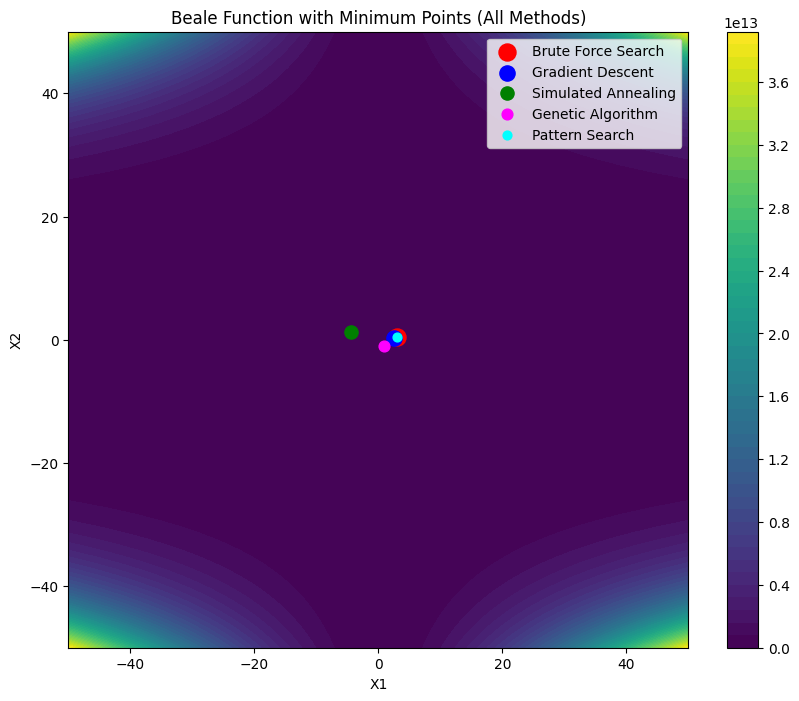

In [188]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of X1, X2 values from -50 to +50
x = np.linspace(-50, 50, 100)
y = np.linspace(-50, 50, 100)
X, Y = np.meshgrid(x, y)

# Beale function calculation
def beale(x):
    x1, x2 = x[0], x[1]
    A, B, C = 1.5, 2.25, 2.625
    return (A - x1 + x1*x2)**2 + (B - x1 + x1*x2**2)**2 + (C - x1 + x1*x2**3)**2

# Calculate Beale function values for the grid
Z = beale(np.array([X, Y]))

# Create contour plot
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(contour)

# Add points found by all methods
plt.scatter(best_x[0], best_x[1], color='red', s=150, label='Brute Force Search')
plt.scatter(best_x_gd[0], best_x_gd[1], color='blue', s=120, label='Gradient Descent')
plt.scatter(best_x_sa[0], best_x_sa[1], color='green', s=90, label='Simulated Annealing')
plt.scatter(best_x_ga[0], best_x_ga[1], color='magenta', s=60, label='Genetic Algorithm')
plt.scatter(best_x_ps[0], best_x_ps[1], color='cyan', s=40, label='Pattern Search')

# Set title, axis labels, and legend
plt.title('Beale Function with Minimum Points (All Methods)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()

# Show plot
plt.show()


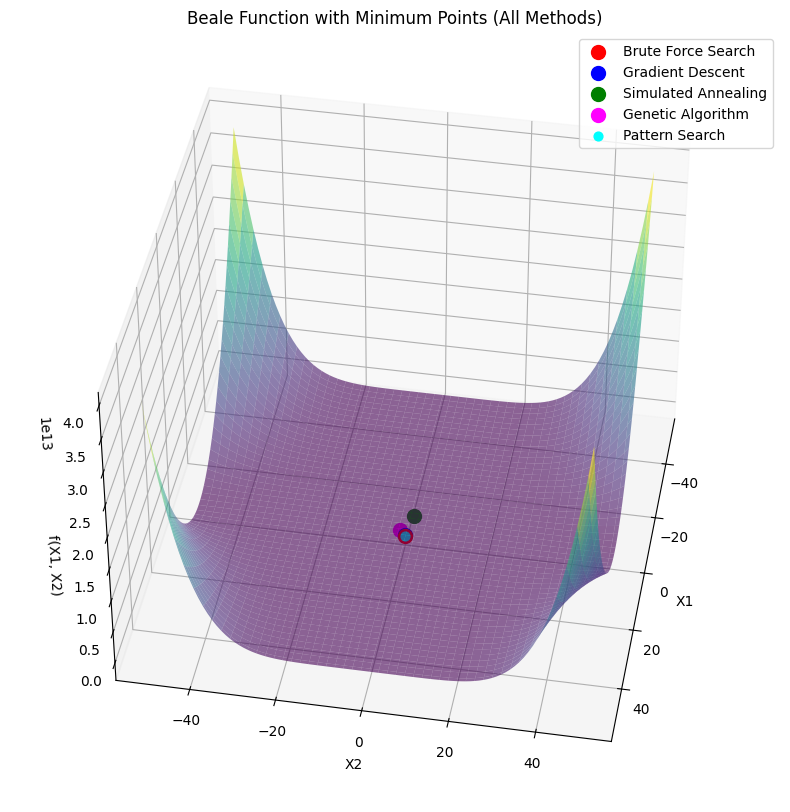

In [189]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of X1, X2 values from -50 to +50
x = np.linspace(-50, 50, 100)
y = np.linspace(-50, 50, 100)
X, Y = np.meshgrid(x, y)

# Beale function calculation
def beale(x):
    x1, x2 = x[0], x[1]
    A, B, C = 1.5, 2.25, 2.625
    return (A - x1 + x1*x2)**2 + (B - x1 + x1*x2**2)**2 + (C - x1 + x1*x2**3)**2

# Calculate Beale function values for the grid
Z = beale(np.array([X, Y]))

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.view_init(elev=40, azim=10)

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)  # alpha for surface transparency

# Add points found by all methods
points = [best_x, best_x_gd, best_x_sa, best_x_ga, best_x_ps]
colors = ['red', 'blue', 'green', 'magenta', 'cyan']
labels = ['Brute Force Search', 'Gradient Descent', 'Simulated Annealing', 'Genetic Algorithm', 'Pattern Search']
sizes = [100, 100, 100, 100, 40]  # Different sizes for the points

for i, point in enumerate(points):
    ax.scatter(point[0], point[1], beale(point), color=colors[i], s=sizes[i], label=labels[i])

# Set title, axis labels, and legend
ax.set_title('Beale Function with Minimum Points (All Methods)')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('f(X1, X2)')
ax.legend()

# Show plot
plt.show()


**Conclusion**

In this task, various optimization techniques were applied to minimize the Beale function, a well-known multimodal benchmark function. The results demonstrate that while all methods have their merits, their effectiveness varies significantly.

Brute Force and Pattern Search (Hooke-Jeeves) successfully identified the global minimum at [3.0, 0.5], with negligible function values close to zero. Despite its accuracy, the brute force method is computationally intensive and impractical for higher-dimensional problems, whereas Pattern Search achieved similar accuracy with far greater efficiency.

Gradient Descent showed moderate success but was affected by the choice of the starting point and learning rate, leading to convergence at a local minimum. Simulated Annealing and Genetic Algorithm, both global optimization methods, failed to reach the true minimum in this instance. Their performance indicates a need for more careful parameter tuning and increased iterations to improve convergence.

Overall, Pattern Search proved to be the most effective and efficient method for this problem. It balanced computational cost and solution accuracy, making it well-suited for optimizing functions with challenging landscapes like the Beale function.